In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../results/figures")

improved_feature_table = pd.read_csv(
    PROCESSED_DATA_DIR / "improved_gait_feature_table.csv"
)

improved_feature_table.head()

,file_name,study,group,subject_id,trial,file_path,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,...,cv_left_peak_force,cv_right_peak_force,mean_left_force_area,mean_right_force_area,cv_left_force_area,cv_right_force_area,stride_time_symmetry_index,swing_time_symmetry_index,peak_force_symmetry_index,force_area_symmetry_index
0,GaCo01_01.txt,Ga,Control,GaCo01,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,98,0.775760,...,0.037178,0.034263,636.697878,695.629409,0.067387,0.087641,0.037116,0.112599,0.046886,0.088464
1,GaCo02_01.txt,Ga,Control,GaCo02,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,102,108,0.841782,...,0.036025,0.055672,480.308172,501.301322,0.051348,0.111153,0.057693,0.188482,0.007789,0.042773
2,GaCo02_02.txt,Ga,Control,GaCo02,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,114,115,0.940815,...,0.035949,0.043696,455.131250,472.647993,0.064599,0.112858,0.003827,0.001324,0.027875,0.037761
3,GaCo03_01.txt,Ga,Control,GaCo03,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,97,0.775760,...,0.029093,0.039508,747.940533,737.130826,0.103255,0.100147,0.025603,0.032140,0.013182,0.014558
4,GaCo03_02.txt,Ga,Control,GaCo03,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,109,108,0.899551,...,0.037278,0.034223,683.531943,674.572292,0.112464,0.045651,0.004825,0.042645,0.043420,0.013194


In [3]:
improved_feature_table.shape

(306, 50)

In [4]:
contact_features = [
    "left_contacts_per_sec",
    "right_contacts_per_sec",
    "mean_left_contact_duration",
    "mean_right_contact_duration",
    "cv_left_contact_duration",
    "cv_right_contact_duration",
]

step_stride_features = [
    "mean_step_time",
    "cv_step_time",
    "mean_left_stride_time",
    "mean_right_stride_time",
    "cv_left_stride_time",
    "cv_right_stride_time",
]

swing_features = [
    "mean_left_swing_time",
    "mean_right_swing_time",
    "cv_left_swing_time",
    "cv_right_swing_time",
]

force_features = [
    "mean_left_peak_force",
    "mean_right_peak_force",
    "cv_left_peak_force",
    "cv_right_peak_force",
    "mean_left_force_area",
    "mean_right_force_area",
    "cv_left_force_area",
    "cv_right_force_area",
]

asymmetry_features = [
    "stride_time_symmetry_index",
    "swing_time_symmetry_index",
    "peak_force_symmetry_index",
    "force_area_symmetry_index",
    "contact_count_difference",
    "mean_contact_duration_difference",
    "cv_contact_duration_difference",
]

features_to_analyze = (
    contact_features
    + step_stride_features
    + swing_features
    + force_features
    + asymmetry_features
)

## Feature groups

The improved feature table contains several interpretable feature groups:

- Contact features: how often and how long each foot touches the ground.
- Step and stride features: rhythm of walking.
- Swing features: how long each foot stays in the air.
- Force features: how strongly the foot loads the ground.
- Asymmetry features: how different the left and right sides are.

This grouping helps interpret the results in a gait-analysis way instead of only looking at isolated numbers.

In [5]:
missing_summary = improved_feature_table[features_to_analyze].isna().sum().sort_values(ascending=False)
missing_summary

left_contacts_per_sec               0
mean_left_peak_force                0
mean_contact_duration_difference    0
contact_count_difference            0
force_area_symmetry_index           0
peak_force_symmetry_index           0
swing_time_symmetry_index           0
stride_time_symmetry_index          0
cv_right_force_area                 0
cv_left_force_area                  0
mean_right_force_area               0
mean_left_force_area                0
cv_right_peak_force                 0
cv_left_peak_force                  0
mean_right_peak_force               0
cv_right_swing_time                 0
right_contacts_per_sec              0
cv_left_swing_time                  0
mean_right_swing_time               0
mean_left_swing_time                0
cv_right_stride_time                0
cv_left_stride_time                 0
mean_right_stride_time              0
mean_left_stride_time               0
cv_step_time                        0
mean_step_time                      0
cv_right_con

In [6]:
missing_summary.to_csv(
    PROCESSED_DATA_DIR / "improved_feature_missing_summary.csv"
)

In [7]:
improved_group_median_summary = improved_feature_table.groupby("group")[features_to_analyze].median()

improved_group_median_summary

,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,mean_step_time,cv_step_time,mean_left_stride_time,mean_right_stride_time,...,mean_right_force_area,cv_left_force_area,cv_right_force_area,stride_time_symmetry_index,swing_time_symmetry_index,peak_force_symmetry_index,force_area_symmetry_index,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
group,,,,,,,,,,,,,,,,,,,,,
Control,0.914830,0.916057,0.687836,0.682939,0.109551,0.118838,0.549325,0.158530,1.093105,1.094350,...,474.179749,0.098534,0.107768,0.005815,0.023857,0.036539,0.038608,1.0,0.008875,0.034473
Parkinson,0.907349,0.907804,0.712676,0.714899,0.128962,0.125734,0.559355,0.275523,1.105480,1.103021,...,502.439404,0.108738,0.115460,0.008746,0.054556,0.042413,0.052364,1.0,0.021305,0.038509


In [8]:
improved_group_median_summary.to_csv(
    PROCESSED_DATA_DIR / "improved_group_median_summary.csv"
)

In [9]:
def plot_feature_by_group(df, feature, ylabel=None, save=False):
    control_values = df[df["group"] == "Control"][feature].dropna()
    parkinson_values = df[df["group"] == "Parkinson"][feature].dropna()
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(
        [control_values, parkinson_values],
        labels=["Control", "Parkinson"]
    )
    
    plt.ylabel(ylabel if ylabel else feature)
    plt.title(f"{feature} by Group")
    
    if save:
        output_path = FIGURES_DIR / f"{feature}_by_group.png"
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    
    plt.show()

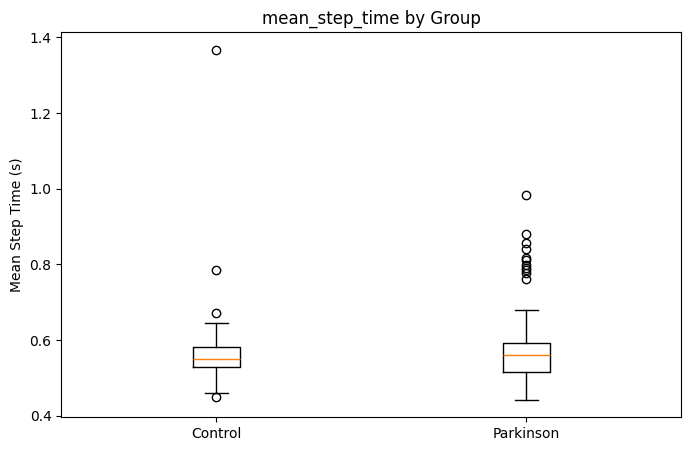

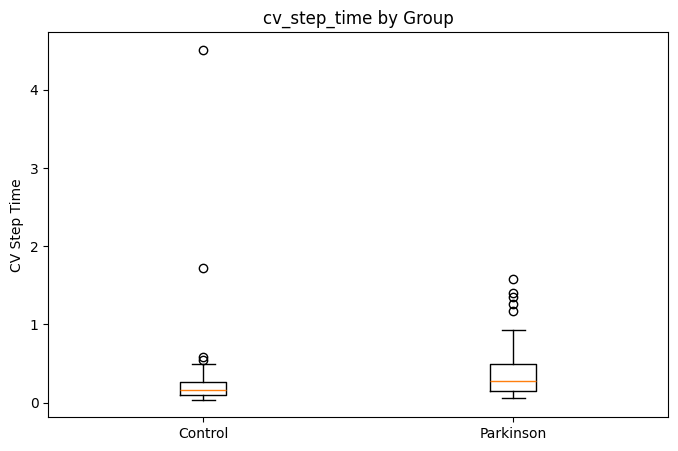

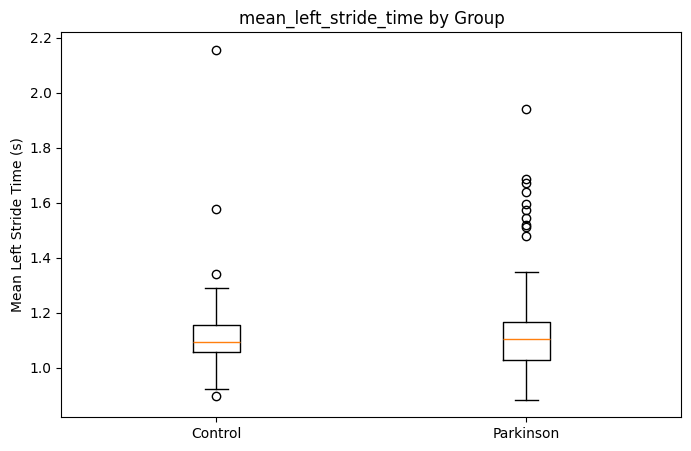

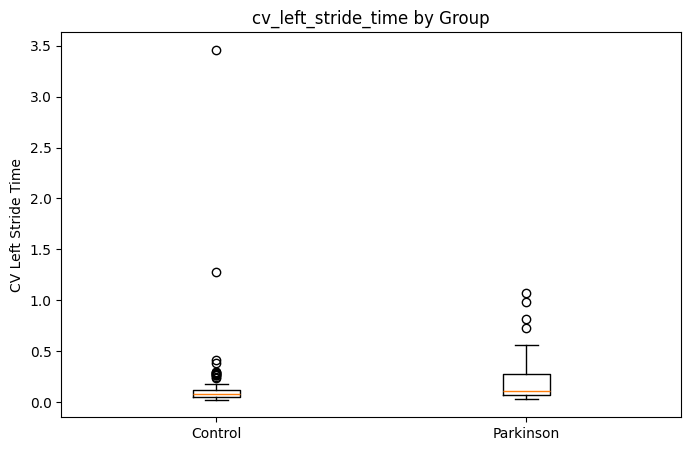

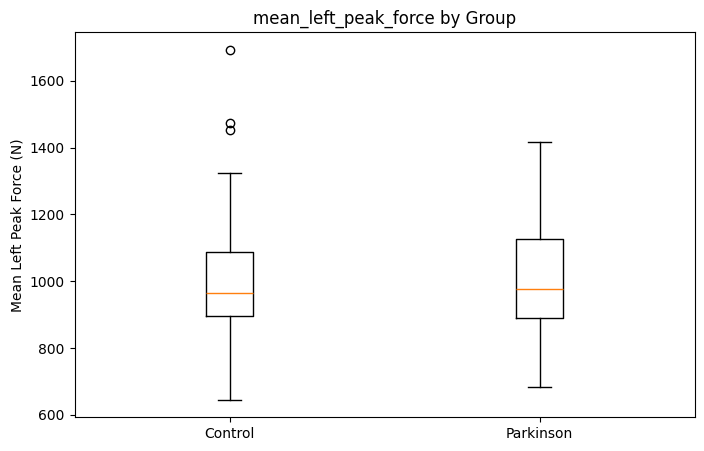

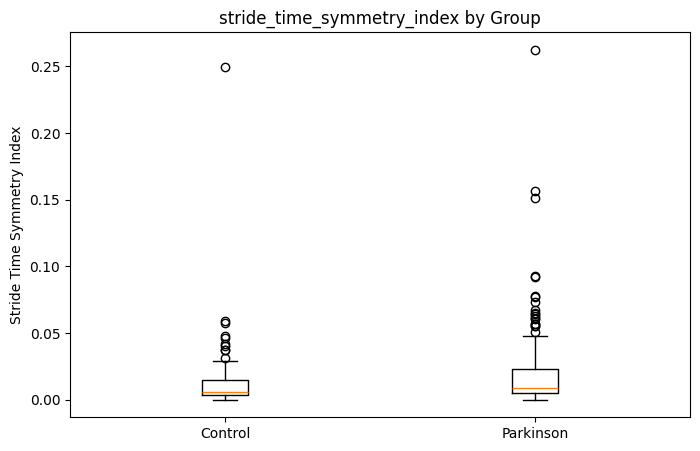

In [10]:
plot_feature_by_group(
    improved_feature_table,
    "mean_step_time",
    ylabel="Mean Step Time (s)",
    save=True
)

plot_feature_by_group(
    improved_feature_table,
    "cv_step_time",
    ylabel="CV Step Time",
    save=True
)

plot_feature_by_group(
    improved_feature_table,
    "mean_left_stride_time",
    ylabel="Mean Left Stride Time (s)",
    save=True
)

plot_feature_by_group(
    improved_feature_table,
    "cv_left_stride_time",
    ylabel="CV Left Stride Time",
    save=True
)

plot_feature_by_group(
    improved_feature_table,
    "mean_left_peak_force",
    ylabel="Mean Left Peak Force (N)",
    save=True
)

plot_feature_by_group(
    improved_feature_table,
    "stride_time_symmetry_index",
    ylabel="Stride Time Symmetry Index",
    save=True
)

In [11]:
def rank_biserial_effect_size(u_statistic, n_control, n_parkinson):
    return (2 * u_statistic) / (n_control * n_parkinson) - 1


def interpret_effect_size(value):
    abs_value = abs(value)
    
    if abs_value < 0.1:
        return "very small"
    elif abs_value < 0.3:
        return "small"
    elif abs_value < 0.5:
        return "medium"
    else:
        return "large"


def benjamini_hochberg_correction(p_values):
    p_values = np.array(p_values)
    n = len(p_values)
    
    sorted_indices = np.argsort(p_values)
    sorted_p_values = p_values[sorted_indices]
    
    corrected = np.empty(n)
    
    for rank, p_value in enumerate(sorted_p_values, start=1):
        corrected[rank - 1] = p_value * n / rank
    
    corrected = np.minimum.accumulate(corrected[::-1])[::-1]
    corrected = np.minimum(corrected, 1.0)
    
    corrected_p_values = np.empty(n)
    corrected_p_values[sorted_indices] = corrected
    
    return corrected_p_values

In [12]:
stat_results = []

for feature in features_to_analyze:
    control_values = improved_feature_table[
        improved_feature_table["group"] == "Control"
    ][feature].dropna()
    
    parkinson_values = improved_feature_table[
        improved_feature_table["group"] == "Parkinson"
    ][feature].dropna()
    
    if len(control_values) == 0 or len(parkinson_values) == 0:
        continue
    
    u_stat, p_value = mannwhitneyu(
        parkinson_values,
        control_values,
        alternative="two-sided"
    )
    
    effect_size = rank_biserial_effect_size(
        u_stat,
        n_control=len(control_values),
        n_parkinson=len(parkinson_values)
    )
    
    stat_results.append({
        "feature": feature,
        "control_median": control_values.median(),
        "parkinson_median": parkinson_values.median(),
        "median_difference_parkinson_minus_control": (
            parkinson_values.median() - control_values.median()
        ),
        "p_value": p_value,
        "rank_biserial_effect_size": effect_size,
        "n_control": len(control_values),
        "n_parkinson": len(parkinson_values)
    })

improved_stat_results = pd.DataFrame(stat_results)

improved_stat_results["p_value_corrected"] = benjamini_hochberg_correction(
    improved_stat_results["p_value"].values
)

improved_stat_results["effect_size_interpretation"] = improved_stat_results[
    "rank_biserial_effect_size"
].apply(interpret_effect_size)

improved_stat_results = improved_stat_results.sort_values(
    "p_value_corrected"
)

improved_stat_results

,feature,control_median,parkinson_median,median_difference_parkinson_minus_control,p_value,rank_biserial_effect_size,n_control,n_parkinson,p_value_corrected,effect_size_interpretation
15,cv_right_swing_time,0.087748,0.126673,0.038924,4.273578e-11,0.475467,92,214,1.324809e-09,medium
25,swing_time_symmetry_index,0.023857,0.054556,0.030699,2.330935e-09,0.430668,92,214,3.612950e-08,medium
29,mean_contact_duration_difference,0.008875,0.021305,0.012431,3.809759e-08,0.396536,92,214,3.936751e-07,medium
7,cv_step_time,0.158530,0.275523,0.116993,1.604122e-07,0.377844,92,214,1.243195e-06,medium
14,cv_left_swing_time,0.086026,0.130944,0.044918,5.194899e-07,0.361896,92,214,3.220837e-06,medium
11,cv_right_stride_time,0.078062,0.106784,0.028723,8.096783e-07,0.355699,92,214,4.183338e-06,medium
10,cv_left_stride_time,0.081512,0.111337,0.029824,1.463034e-05,0.312525,92,214,6.479150e-05,medium
13,mean_right_swing_time,0.399366,0.375311,-0.024055,3.788580e-05,-0.297085,92,214,1.468075e-04,small
12,mean_left_swing_time,0.399713,0.378939,-0.020775,1.530497e-04,-0.273009,92,214,5.271710e-04,small
24,stride_time_symmetry_index,0.005815,0.008746,0.002931,3.427346e-03,0.211042,92,214,1.062477e-02,small


In [13]:
improved_stat_results.to_csv(
    PROCESSED_DATA_DIR / "improved_feature_statistical_comparison.csv",
    index=False
)

In [14]:
feature_group_map = {}

for feature in contact_features:
    feature_group_map[feature] = "contact"

for feature in step_stride_features:
    feature_group_map[feature] = "step_stride"

for feature in swing_features:
    feature_group_map[feature] = "swing"

for feature in force_features:
    feature_group_map[feature] = "force"

for feature in asymmetry_features:
    feature_group_map[feature] = "asymmetry"

improved_stat_results["feature_group"] = improved_stat_results["feature"].map(feature_group_map)

improved_stat_results[
    [
        "feature_group",
        "feature",
        "control_median",
        "parkinson_median",
        "p_value_corrected",
        "rank_biserial_effect_size",
        "effect_size_interpretation"
    ]
]

,feature_group,feature,control_median,parkinson_median,p_value_corrected,rank_biserial_effect_size,effect_size_interpretation
15,swing,cv_right_swing_time,0.087748,0.126673,1.324809e-09,0.475467,medium
25,asymmetry,swing_time_symmetry_index,0.023857,0.054556,3.612950e-08,0.430668,medium
29,asymmetry,mean_contact_duration_difference,0.008875,0.021305,3.936751e-07,0.396536,medium
7,step_stride,cv_step_time,0.158530,0.275523,1.243195e-06,0.377844,medium
14,swing,cv_left_swing_time,0.086026,0.130944,3.220837e-06,0.361896,medium
11,step_stride,cv_right_stride_time,0.078062,0.106784,4.183338e-06,0.355699,medium
10,step_stride,cv_left_stride_time,0.081512,0.111337,6.479150e-05,0.312525,medium
13,swing,mean_right_swing_time,0.399366,0.375311,1.468075e-04,-0.297085,small
12,swing,mean_left_swing_time,0.399713,0.378939,5.271710e-04,-0.273009,small
24,asymmetry,stride_time_symmetry_index,0.005815,0.008746,1.062477e-02,0.211042,small


In [15]:
improved_stat_results.to_csv(
    PROCESSED_DATA_DIR / "improved_feature_statistical_comparison.csv",
    index=False
)

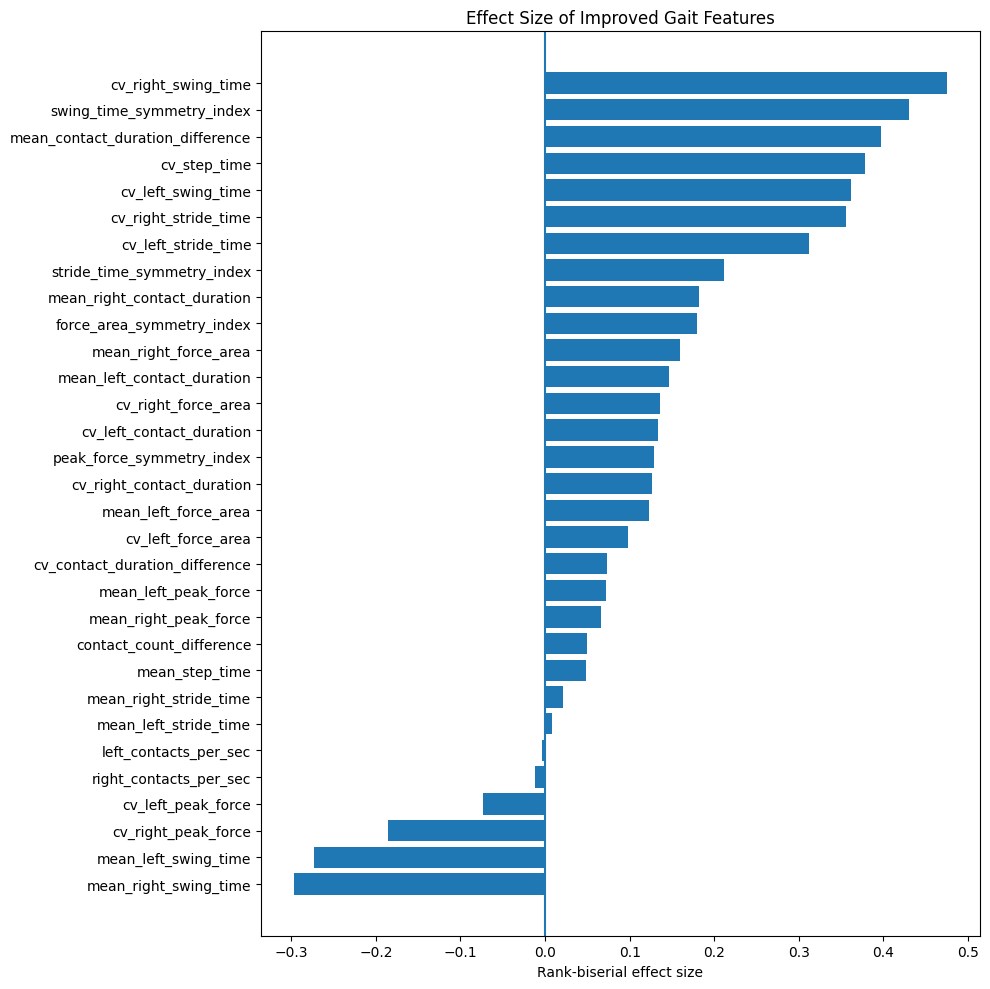

In [16]:
effect_table = improved_stat_results.sort_values(
    "rank_biserial_effect_size"
)

plt.figure(figsize=(10, 10))
plt.barh(
    effect_table["feature"],
    effect_table["rank_biserial_effect_size"]
)
plt.axvline(0)
plt.xlabel("Rank-biserial effect size")
plt.title("Effect Size of Improved Gait Features")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "improved_gait_feature_effect_sizes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
study_stat_results = []

for study in sorted(improved_feature_table["study"].unique()):
    study_df = improved_feature_table[
        improved_feature_table["study"] == study
    ]
    
    for feature in features_to_analyze:
        control_values = study_df[
            study_df["group"] == "Control"
        ][feature].dropna()
        
        parkinson_values = study_df[
            study_df["group"] == "Parkinson"
        ][feature].dropna()
        
        if len(control_values) == 0 or len(parkinson_values) == 0:
            continue
        
        u_stat, p_value = mannwhitneyu(
            parkinson_values,
            control_values,
            alternative="two-sided"
        )
        
        effect_size = rank_biserial_effect_size(
            u_stat,
            n_control=len(control_values),
            n_parkinson=len(parkinson_values)
        )
        
        study_stat_results.append({
            "study": study,
            "feature": feature,
            "feature_group": feature_group_map.get(feature),
            "control_median": control_values.median(),
            "parkinson_median": parkinson_values.median(),
            "median_difference_parkinson_minus_control": (
                parkinson_values.median() - control_values.median()
            ),
            "p_value": p_value,
            "rank_biserial_effect_size": effect_size,
            "effect_size_interpretation": interpret_effect_size(effect_size),
            "n_control": len(control_values),
            "n_parkinson": len(parkinson_values)
        })

study_improved_stat_results = pd.DataFrame(study_stat_results)

study_improved_stat_results.head()

,study,feature,feature_group,control_median,parkinson_median,median_difference_parkinson_minus_control,p_value,rank_biserial_effect_size,effect_size_interpretation,n_control,n_parkinson
0,Ga,left_contacts_per_sec,contact,0.911931,0.891299,-0.020632,0.679161,-0.048070,very small,38,75
1,Ga,right_contacts_per_sec,contact,0.920183,0.883046,-0.037137,0.543136,-0.070526,very small,38,75
2,Ga,mean_left_contact_duration,contact,0.681066,0.741280,0.060214,0.013267,0.286316,small,38,75
3,Ga,mean_right_contact_duration,contact,0.677908,0.750034,0.072126,0.014684,0.282105,small,38,75
4,Ga,cv_left_contact_duration,contact,0.114367,0.125965,0.011598,0.815001,-0.027368,very small,38,75


In [18]:
study_improved_stat_results.to_csv(
    PROCESSED_DATA_DIR / "study_wise_improved_feature_statistical_comparison.csv",
    index=False
)

In [19]:
direction_table = study_improved_stat_results.copy()

direction_table["direction"] = np.where(
    direction_table["rank_biserial_effect_size"] > 0,
    "Parkinson higher",
    "Control higher"
)

direction_summary = (
    direction_table
    .groupby(["feature_group", "feature", "direction"])
    .size()
    .reset_index(name="count")
)

direction_pivot = direction_summary.pivot_table(
    index=["feature_group", "feature"],
    columns="direction",
    values="count",
    fill_value=0
).reset_index()

direction_pivot

direction,feature_group,feature,Control higher,Parkinson higher
0,asymmetry,contact_count_difference,0.0,3.0
1,asymmetry,cv_contact_duration_difference,2.0,1.0
2,asymmetry,force_area_symmetry_index,0.0,3.0
3,asymmetry,mean_contact_duration_difference,0.0,3.0
4,asymmetry,peak_force_symmetry_index,1.0,2.0
5,asymmetry,stride_time_symmetry_index,1.0,2.0
6,asymmetry,swing_time_symmetry_index,0.0,3.0
7,contact,cv_left_contact_duration,1.0,2.0
8,contact,cv_right_contact_duration,1.0,2.0
9,contact,left_contacts_per_sec,2.0,1.0


In [20]:
direction_pivot.to_csv(
    PROCESSED_DATA_DIR / "improved_feature_direction_consistency.csv",
    index=False
)

In [21]:
top_features = improved_stat_results.copy()

top_features["abs_effect_size"] = top_features[
    "rank_biserial_effect_size"
].abs()

top_features = top_features.sort_values(
    ["p_value_corrected", "abs_effect_size"],
    ascending=[True, False]
)

top_features[
    [
        "feature_group",
        "feature",
        "control_median",
        "parkinson_median",
        "p_value_corrected",
        "rank_biserial_effect_size",
        "effect_size_interpretation"
    ]
].head(15)

,feature_group,feature,control_median,parkinson_median,p_value_corrected,rank_biserial_effect_size,effect_size_interpretation
15,swing,cv_right_swing_time,0.087748,0.126673,1.324809e-09,0.475467,medium
25,asymmetry,swing_time_symmetry_index,0.023857,0.054556,3.612950e-08,0.430668,medium
29,asymmetry,mean_contact_duration_difference,0.008875,0.021305,3.936751e-07,0.396536,medium
7,step_stride,cv_step_time,0.158530,0.275523,1.243195e-06,0.377844,medium
14,swing,cv_left_swing_time,0.086026,0.130944,3.220837e-06,0.361896,medium
11,step_stride,cv_right_stride_time,0.078062,0.106784,4.183338e-06,0.355699,medium
10,step_stride,cv_left_stride_time,0.081512,0.111337,6.479150e-05,0.312525,medium
13,swing,mean_right_swing_time,0.399366,0.375311,1.468075e-04,-0.297085,small
12,swing,mean_left_swing_time,0.399713,0.378939,5.271710e-04,-0.273009,small
24,asymmetry,stride_time_symmetry_index,0.005815,0.008746,1.062477e-02,0.211042,small


In [22]:
top_features.to_csv(
    PROCESSED_DATA_DIR / "top_improved_gait_features.csv",
    index=False
)

## Milestone 6B conclusion

This notebook compared the improved gait feature table between Control and Parkinson recordings.

Compared with the earlier contact-only feature set, the improved table includes step timing, stride timing, swing timing, force loading, and left-right asymmetry features. These features provide a more detailed description of gait rhythm and balance.

The analysis used descriptive summaries, boxplots, Mann–Whitney U tests, corrected p-values, and rank-biserial effect sizes. Study-wise analysis was also included to check whether feature differences are consistent across Ga, Ju, and Si recordings.

The most promising features are those that show interpretable group differences, meaningful effect sizes, and consistent direction across study groups.